# DEtection TRansformer (DETR)

Pros:

1. No region proposal tuning
2. Sigle stage pipeline
3. Single loss function

Cons:

1.   Data hungry
2.   Strugles with small objects
3.   Too big to fit in mobile


Requires:

> The follicle data be loaded into drive or directly into colab runtime environment.
> The fine-tuned model is in my drive. I can share if needed (to avoid re-trianing).

Key Param:

The number of decoder queries is set to 100. Given that the median number of objects per image is 12, this value can be reduced to help minimize overlapping predictions.



In [2]:
import os
import xml.etree.ElementTree as ET
from dataclasses import dataclass
from typing import List, Dict, Any

import torch
from torch.utils.data import Dataset
from PIL import Image, ImageDraw, ImageFont

from transformers import (
    DetrImageProcessor,
    DetrForObjectDetection,
    TrainingArguments,
    Trainer
)

import pandas as pd
import matplotlib.pyplot as plt
import json
from transformers import DetrConfig

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!cp -r /content/drive/MyDrive/data /content/


In [6]:
# ============================================================
# CONFIG: setting params
# ============================================================

@dataclass
class Config:
    train_image_dir: str = "/content/data/Images"
    train_annot_dir: str = "/content/data/Annotations"

    pretrained_model_name: str = "facebook/detr-resnet-50"
    output_dir: str = "./detr_voc_finetuned"

    class_names: List[str] = None
    image_size: int = 800 # this is default value at which the resnet is trained

    per_device_train_batch_size: int = 2
    per_device_eval_batch_size: int = 2
    num_train_epochs: int = 5
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    num_workers: int = 2 # number of CPU to load dataloader
    save_total_limit: int = 2 # keep only latest 2 checkpoint

    def __post_init__(self):
        # classes
        if self.class_names is None:
            self.class_names = ['premium','single','undersize','abnormal']


cfg = Config()

# Pascal VOC class ids must start from 0
id2label = {i: name for i, name in enumerate(cfg.class_names)}
label2id = {name: i for i, name in id2label.items()}


In [7]:
# load training and validation file names
train_files =[]
val_files = []
with open('/content/data/ImageSets/Main/train.txt') as f:
    lines = f.readlines()
    train_files =[fnm[:-1] for fnm in lines]

with open('/content/data/ImageSets/Main/val.txt') as f:
    lines = f.readlines()
    val_files =[fnm[:-1] for fnm in lines]

In [8]:

# ============================================================
# XML Parser and bbox fixer
# ============================================================

def clip_box_xyxy(box, width, height):
    x1, y1, x2, y2 = box
    x1 = max(0.0, min(float(x1), width - 1))
    y1 = max(0.0, min(float(y1), height - 1))
    x2 = max(0.0, min(float(x2), width - 1))
    y2 = max(0.0, min(float(y2), height - 1))
    return [x1, y1, x2, y2]

def is_valid_xyxy(box):
    x1, y1, x2, y2 = box
    return (x2 > x1) and (y2 > y1)
#coco style bounding box
def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    return [x1, y1, x2 - x1, y2 - y1]

def parse_voc_xml(xml_path: str, label2id: Dict[str, int]) -> Dict[str, Any]:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    width = int(size.findtext("width"))
    height = int(size.findtext("height"))

    objects = []
    for obj in root.findall("object"):
        name = obj.findtext("name")
        if name is None:
            name = obj.findtext("class")
        if name is None:
            continue

        name = name.strip().lower()
        if name not in label2id:
            continue

        bndbox = obj.find("bndbox")
        if bndbox is None:
            continue

        xmin = float(bndbox.findtext("xmin"))
        ymin = float(bndbox.findtext("ymin"))
        xmax = float(bndbox.findtext("xmax"))
        ymax = float(bndbox.findtext("ymax"))

        # Repair reversed coordinates
        x1, x2 = sorted([xmin, xmax])
        y1, y2 = sorted([ymin, ymax])

        # Clip to XML-declared image size
        x1 = max(0.0, min(x1, width - 1))
        y1 = max(0.0, min(y1, height - 1))
        x2 = max(0.0, min(x2, width - 1))
        y2 = max(0.0, min(y2, height - 1))

        if x2 <= x1 or y2 <= y1:
            continue

        difficult = obj.findtext("difficult")
        difficult = int(difficult) if difficult is not None else 0

        objects.append({
            "name": name,
            "class_id": label2id[name],
            "bbox_xyxy": [x1, y1, x2, y2],
            "difficult": difficult,#how difficult is the object to detect
        })

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "objects": objects,
    }

#create data set
class PascalVOCDataset(Dataset):
    def __init__(self, image_dir, annot_dir, processor, label2id, split):
        self.image_dir = image_dir
        self.annot_dir = annot_dir
        self.processor = processor
        self.label2id = label2id
        self.split = set(split) # unique list

        self.xml_files = sorted([
            f for f in os.listdir(annot_dir)
            if f.endswith(".xml") and os.path.splitext(f)[0] in self.split
        ])

    def __len__(self):
        return len(self.xml_files)

    def __getitem__(self, idx):
        xml_file = self.xml_files[idx]
        xml_path = os.path.join(self.annot_dir, xml_file)

        parsed = parse_voc_xml(xml_path, self.label2id)

        image_filename = parsed["filename"]
        image_path = os.path.join(self.image_dir, image_filename)

        if not os.path.exists(image_path):
            stem = os.path.splitext(xml_file)[0]
            found = False
            for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
                alt_path = os.path.join(self.image_dir, stem + ext)
                if os.path.exists(alt_path):
                    image_path = alt_path
                    found = True
                    break
            if not found:
                raise FileNotFoundError(f"Image not found for XML: {xml_path}")

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        annotations = []
        ann_id = 0

        for obj in parsed["objects"]:
            box_xyxy = clip_box_xyxy(obj["bbox_xyxy"], width, height)
            if not is_valid_xyxy(box_xyxy):
                continue

            #coc style
            x, y, w, h = xyxy_to_xywh(box_xyxy)
            if w <= 0 or h <= 0:
                continue

            annotations.append({
                "id": ann_id,
                "image_id": idx,
                "category_id": int(obj["class_id"]),
                "bbox": [float(x), float(y), float(w), float(h)],
                "area": float(w * h),
                "iscrowd": 0, #Coco style: individual object per box
            })
            ann_id += 1

        target = {
            "image_id": idx,
            "annotations": annotations,
        }

        encoding = self.processor(
            images=image,
            annotations=target,
            return_tensors="pt",
        )

        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),# resized and normalized
            "labels": encoding["labels"][0], # class and bounding boxes
        }


processor = DetrImageProcessor.from_pretrained(
    cfg.pretrained_model_name,
    size={"shortest_edge": cfg.image_size, "longest_edge": 1333},
)

# Make data ready to be consumed by loader
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    labels = [item["labels"] for item in batch]

    #Same shape images with in a batch
    padded = processor.pad(pixel_values, return_tensors="pt")

    return {
        "pixel_values": padded["pixel_values"],
        "pixel_mask": padded["pixel_mask"],
        "labels": labels,
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

In [9]:
# ============================================================
# Create Dataset
# ============================================================

train_dataset = PascalVOCDataset(
    image_dir=cfg.train_image_dir,
    annot_dir=cfg.train_annot_dir,
    processor=processor,
    label2id=label2id,
    split= train_files
)

val_dataset = PascalVOCDataset(
    image_dir=cfg.train_image_dir,
    annot_dir=cfg.train_annot_dir,
    processor=processor,
    label2id=label2id,
    split= val_files
)

In [10]:


# ============================================================
# TRAINING ARGS
# ============================================================

training_args = TrainingArguments(
    output_dir=cfg.output_dir,
    per_device_train_batch_size=cfg.per_device_train_batch_size,
    per_device_eval_batch_size=cfg.per_device_eval_batch_size,
    num_train_epochs= cfg.num_train_epochs,

    learning_rate=1e-5,
    weight_decay=cfg.weight_decay,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    save_total_limit=cfg.save_total_limit,
    remove_unused_columns=False,
    dataloader_num_workers=cfg.num_workers,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,#minimize loss

    fp16=False,   #caused OOM
    max_grad_norm=1.0,
    warmup_steps=500,# learning rate increases over 500 steps
)


Model Training:

Fine tune entire parameters: It is suggested to tune both Resnet and Transformer together for co-adaptation.


In [11]:
# Fine tune a model or load from checkpoint if exists
from transformers.utils import logging
logging.set_verbosity_error()

save_path = "/content/drive/MyDrive/detr_follicle_model"
hist_path ="/content/drive/MyDrive/detr_follicle_model/training_log_history.json"
logs=''
if os.path.exists(os.path.join(save_path, "config.json")):
    print("Loading existing model from Drive...")

    model = DetrForObjectDetection.from_pretrained(save_path)
    processor = DetrImageProcessor.from_pretrained(save_path)
    with open(hist_path, "r") as f:
      logs = json.load(f)
else:
    print(" No saved model found. Training new model...")

    # ---- initialize model ---
    config = DetrConfig.from_pretrained(cfg.pretrained_model_name)
    config.num_queries = 100
    config.num_labels = len(cfg.class_names)
    config.id2label = id2label
    config.label2id = label2id

    model = DetrForObjectDetection.from_pretrained(
        cfg.pretrained_model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    # ---- train ----
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=processor,
        data_collator=collate_fn,
    )

    trainer.train()

    # ---- save ----
    logs= trainer.state.log_history
    trainer.save_model(save_path)          # saves model weights + config
    processor.save_pretrained(save_path)   # saves image processor

    with open(os.path.join(save_path, "training_log_history.json"), "w") as f:
      json.dump(trainer.state.log_history, f, indent=2) # save history

    print("Model saved to Drive.")

Loading existing model from Drive...


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

# Model Summary

In [12]:
#params
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Layers
encoder_layers = model.config.encoder_layers
decoder_layers = model.config.decoder_layers

# Attention heads

num_heads = model.config.encoder_attention_heads

# Backbone params (ResNet)
backbone_params = sum(p.numel() for p in model.model.backbone.parameters())

# Transformer params
transformer_params = sum(p.numel() for p in model.model.encoder.parameters()) + \
                     sum(p.numel() for p in model.model.decoder.parameters())

print("DETR Model Summary")
print("=" * 40)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Encoder Layers: {encoder_layers}")
print(f"Decoder Layers: {decoder_layers}")
print(f"Attention Heads: {num_heads}")
print(f"Resnet Backbone Params: {backbone_params:,}")
print(f"Transformer Params: {transformer_params:,}")

DETR Model Summary
Total Parameters: 41,502,409
Trainable Parameters: 41,502,409
Encoder Layers: 6
Decoder Layers: 6
Attention Heads: 8
Resnet Backbone Params: 23,454,912
Transformer Params: 17,363,456


In [13]:
# Output layers
config= model.config
num_classes = config.num_labels   # includes "no-object" class

# Classification head
class_embed = model.class_labels_classifier

# Bounding box head (MLP)
bbox_embed = model.bbox_predictor

#  Object queries

num_queries = config.num_queries

print(f"Number of Queries: {num_queries}")

print(f"Number of Classes (including no-object): {num_classes}")
print(f"Classification Head: {class_embed}") # 4 + 1 for no_class
print(f"Bounding Box Head: {bbox_embed}")



Number of Queries: 100
Number of Classes (including no-object): 4
Classification Head: Linear(in_features=256, out_features=5, bias=True)
Bounding Box Head: DetrMLPPredictionHead(
  (layers): ModuleList(
    (0-1): 2 x Linear(in_features=256, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [14]:
#processor info
size = processor.size
image_mean = processor.image_mean
image_std = processor.image_std
format = processor.format
print(f"Resize: {size}")
print(f"Normalization Mean: {image_mean}")
print(f"Normalization Std: {image_std}")
print(f"Annotation Format: {format}")

Resize: {'longest_edge': 1333, 'shortest_edge': 800}
Normalization Mean: [0.485, 0.456, 0.406]
Normalization Std: [0.229, 0.224, 0.225]
Annotation Format: coco_detection


COST (Hungarian algorithm):

As the target boxes and queiries are unordered and also are not neccesarily equal in number, prediction and target matching has to be done before calculating loss. Loss would be defined between matched target and predictions.

COST: Between target i and prediction j

$$
C_{i,j} = \lambda_{class}*Classcost_{ij} +  \lambda_{bbox}*L_{bbox_{ij}} + \lambda_{giou}*L_{giou_{ij}}
$$
where:

- $Classcost_{ij}$  = -log$p_{ij}$ , $p_{ij}$ is probability f correct class.


LOSS:
$$
L = \lambda_{class}*L_{class} + \lambda_{bbox}*L_{bbox} + \lambda_{giou}*L_{giou}
$$

Where:
- $L_{class}$ =  Cross-entropy loss
- $L_{bbox}$ = $L_{1}$ loss of GT and predicted box coordinates
- $L_{giou}$ = 1 - GIOU (generalized IOU)

Note $\lambda_{class}$ is set to 1 and is not tunable.



In [15]:
# Loss Hyper parameters:
print("Class cost:", config.class_cost)
print("BBox cost:", config.bbox_cost)
print("GIoU cost:", config.giou_cost)

print("BBox loss coef:", config.bbox_loss_coefficient)
print("GIoU loss coef:", config.giou_loss_coefficient)
print("EOS coef (no-object weight):", config.eos_coefficient) # used in cross entropy to weight no-object class

Class cost: 1
BBox cost: 5
GIoU cost: 2
BBox loss coef: 5
GIoU loss coef: 2
EOS coef (no-object weight): 0.1


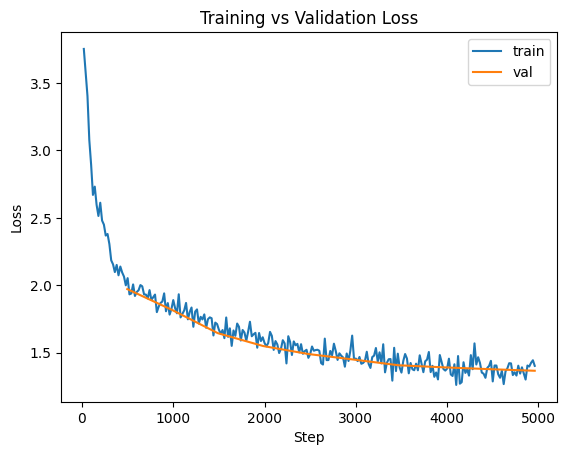

In [16]:

#logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_loss = df[df["loss"].notna()]
val_loss = df[df["eval_loss"].notna()]

plt.plot(train_loss["step"], train_loss["loss"], label="train")
plt.plot(val_loss["step"], val_loss["eval_loss"], label="val")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

In [17]:

# ============================================================
# INFERENCE
# ============================================================

def draw_boxes(image, boxes, labels, color, width=2):
    draw = ImageDraw.Draw(image)

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
        draw.text((x1, y1), label, fill=color)

    return image


def predict_and_draw(
    image_path,
    model,
    processor,
    id2label,
    gt_boxes=None,        # list of [x1,y1,x2,y2]
    gt_labels=None,       # list of class ids
    threshold=0.5,
    device=None
):
    if device is None:
        if torch.cuda.is_available():
            device = "cuda"
        elif torch.backends.mps.is_available():
            device = "mps"
        else:
            device = "cpu"

    model.to(device)
    model.eval()

    image = Image.open(image_path).convert("RGB")

    # -------- Prediction --------
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]], device=device)

    results = processor.post_process_object_detection(
        outputs=outputs,
        threshold=threshold,
        target_sizes=target_sizes
    )[0]

    pred_boxes = results["boxes"].cpu().numpy()
    pred_labels = results["labels"].cpu().numpy()
    pred_scores = results["scores"].cpu().numpy()

    pred_label_names = [
        f"{id2label[int(l)]}:{round(float(s),2)}"
        for l, s in zip(pred_labels, pred_scores)
    ]
    print(len(pred_boxes),len(gt_boxes))
    print(pred_scores)
    # -------- Draw --------
    image_draw = image.copy()

    # Draw ground truth (GREEN)
    if gt_boxes is not None and len(gt_boxes) > 0:
        gt_label_names = [id2label[int(l)] for l in gt_labels]
        image_draw = draw_boxes(image_draw, gt_boxes, gt_label_names, color="green")

    # Draw predictions (RED)
    image_draw = draw_boxes(image_draw, pred_boxes, pred_label_names, color="red")

    return image_draw

In [18]:
# Run test on single test image
#test
xml_path = '/content/data/Annotations/220105_A095_2.xml'
image_path = "/content/data/Images/220105_A095_2.jpg"
parsed = parse_voc_xml(xml_path, label2id)

gt_boxes = [obj["bbox_xyxy"] for obj in parsed["objects"]]
gt_labels = [obj["class_id"] for obj in parsed["objects"]]

img = predict_and_draw(
    image_path,
    model,
    processor,
    id2label,
    gt_boxes=gt_boxes,
    gt_labels=gt_labels,
    threshold=0.5
)

img.show()

19 14
[0.64537287 0.67223436 0.6141554  0.71681064 0.547079   0.6349267
 0.6206774  0.52706736 0.6237145  0.6353911  0.6080151  0.6975108
 0.72727454 0.59187514 0.6228392  0.60073274 0.7156168  0.54639214
 0.6049796 ]


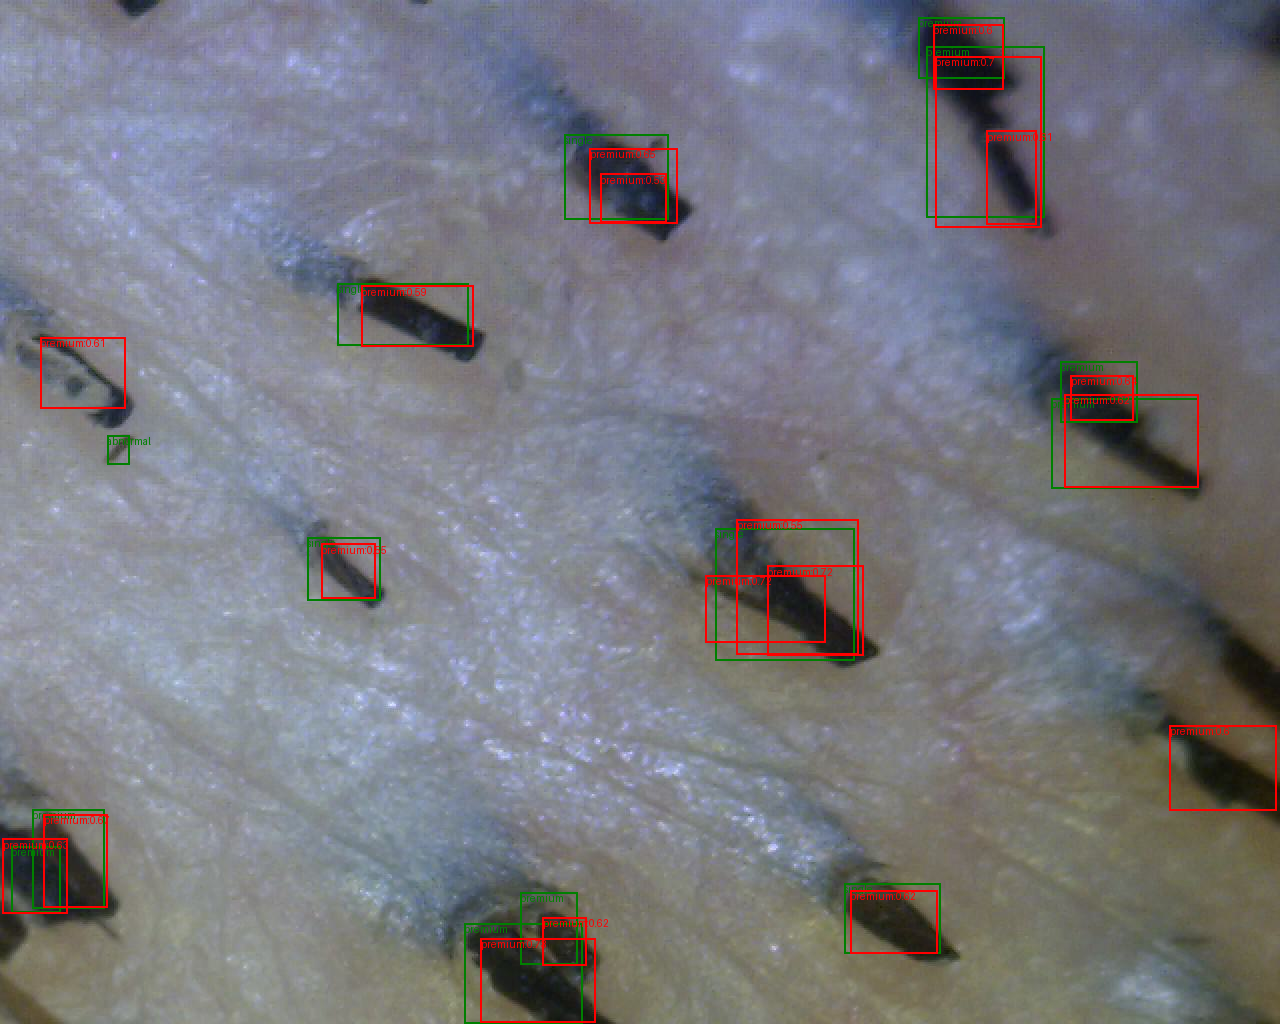

In [19]:
img

# Further work:

1. The model defaults to predicting the premium class, likely due to class imbalance. Further tuning is needed to address this issue.
2. Further tuning for better box detection

# Advanced EDA

#### 1. FFT: light brightness variation

Low frequency blob indicates that there is brightness variation

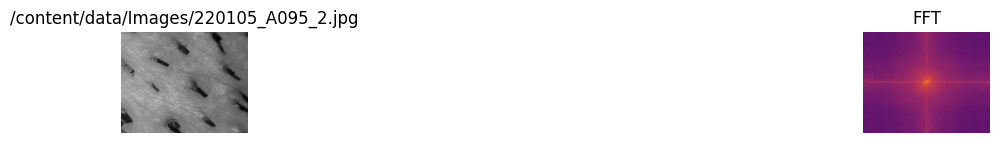

In [20]:
#FFT
#Lighting brightness
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

img_files= [image_path]

plt.figure(figsize=(15, 12))

for i, fname in enumerate(img_files):
    path = os.path.join('FDU_HairFollicleDataset/images/', fname)

    # Load + grayscale
    img_color = cv2.imread(path)
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # FFT
    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(1 + np.abs(fshift))

    # Normalize (optional but better visualization)
    magnitude = magnitude / magnitude.max()

    # Plot original
    plt.subplot(10, 2, 2*i + 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title(f"{fname}")
    plt.axis('off')

    # Plot FFT
    plt.subplot(10, 2, 2*i + 2)
    plt.imshow(magnitude, cmap='inferno')
    plt.title("FFT")
    plt.axis('off')

plt.tight_layout()
plt.show()

#### 2. Merging overlapping boxes

In [21]:
def box_area(box):
    x1, y1, x2, y2 = box
    return max(0, x2 - x1) * max(0, y2 - y1)

def intersection_area(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    #print(ix2 - ix1,iy2 - iy1)
    return max(0, ix2 - ix1) * max(0, iy2 - iy1)

def overlap_over_smaller(a, b):
    #print(a,b)
    inter = intersection_area(a, b)
    #print(inter)
    small_area = min(box_area(a), box_area(b))

    if small_area == 0:
        return 0
    #print(inter/small_area )
    return inter / small_area

def merge_two_boxes(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    return [
        min(ax1, bx1),
        min(ay1, by1),
        max(ax2, bx2),
        max(ay2, by2)
    ]

def merge_overlapping_boxes(boxes, threshold=0.20):
    """
    boxes: list of [x1, y1, x2, y2]
    threshold: overlap / smaller_box_area threshold
    """

    boxes = [list(map(float, b)) for b in boxes]
    changed = True

    while changed:
        changed = False
        merged = []
        used = [False] * len(boxes)

        for i in range(len(boxes)):
            if used[i]:
                continue

            current = boxes[i]
            used[i] = True

            for j in range(i + 1, len(boxes)):
                if used[j]:
                    continue

                ratio = overlap_over_smaller(current, boxes[j])

                if ratio >= threshold:
                    current = merge_two_boxes(current, boxes[j])
                    used[j] = True
                    changed = True

            merged.append(current)

        boxes = merged

    return boxes

(np.float64(-0.5), np.float64(1279.5), np.float64(1023.5), np.float64(-0.5))

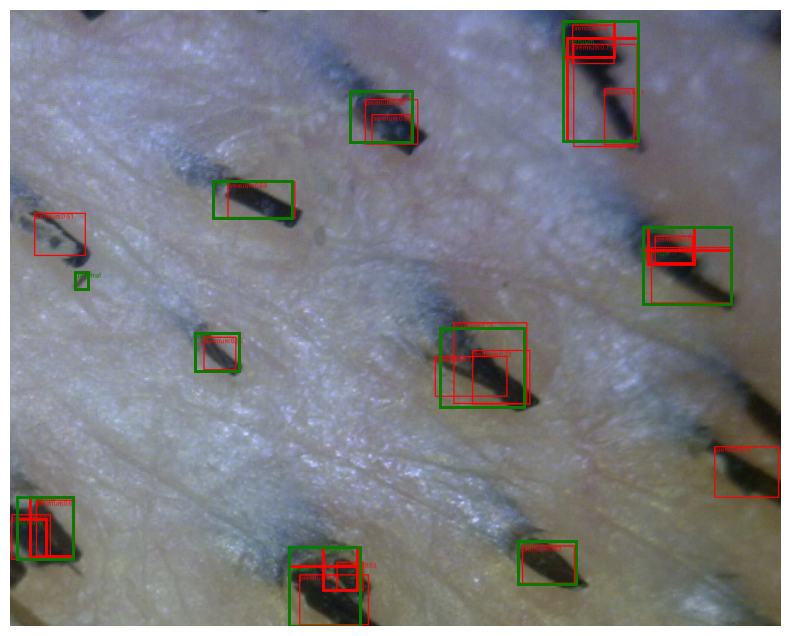

In [22]:
import matplotlib.patches as patches
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
for row in gt_boxes:
    rect = patches.Rectangle(
        (row[0], row[1]),
        row[2] - row[0],
        row[3] - row[1],
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)
    #ax.text(row[0], row[1], str(row["class"]), color="yellow", fontsize=8)

merged_boxes = merge_overlapping_boxes(gt_boxes, 0.2)
#print(len(boxes), len(merged_boxes))
for row in merged_boxes:
  rect = patches.Rectangle(
          (row[0], row[1]),
          row[2] - row[0],
          row[3] - row[1],
          linewidth=2,
          edgecolor="green",
          facecolor="none"
      )
  ax.add_patch(rect)
plt.axis("off")


# Data Aumentation

#### 1.High pass filter

The is low frequency blob indicating light brightness variation. We can apply high pass filter to generate images for data augmentation.

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import cv2
import numpy as np
import matplotlib.pyplot as plt

def fft_highpass_enhanced_color(
    image_path,
    radius=25,
    blend_original=0.65,
    blend_highpass=0.75,
    beta=10,
    use_clahe=True
):
    """
    FFT high-pass enhancement on luminance channel, returned as color image.
    Keeps color while enhancing edges/follicle structures.
    """

    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    # Convert to LAB so we only modify brightness/structure
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)

    # FFT on L channel
    f = np.fft.fft2(L)
    fshift = np.fft.fftshift(f)

    h, w = L.shape
    cy, cx = h // 2, w // 2

    # Circular high-pass mask
    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)

    mask = np.ones((h, w), dtype=np.float32)
    mask[dist <= radius] = 0

    # Apply high-pass filter
    fshift_filtered = fshift * mask

    # Inverse FFT
    L_hp = np.fft.ifft2(np.fft.ifftshift(fshift_filtered))
    L_hp = np.abs(L_hp)

    # Normalize high-pass result to visible range
    L_hp = cv2.normalize(L_hp, None, 0, 255, cv2.NORM_MINMAX)
    L_hp = L_hp.astype(np.uint8)

    # Optional contrast enhancement
    if use_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        L_hp = clahe.apply(L_hp)

    # Blend original luminance + high-pass detail
    L_enhanced = cv2.addWeighted(
        L,
        blend_original,
        L_hp,
        blend_highpass,
        beta
    )

    L_enhanced = np.clip(L_enhanced, 0, 255).astype(np.uint8)

    # Merge back color channels
    lab_enhanced = cv2.merge([L_enhanced, A, B])
    enhanced_bgr = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)

    return enhanced_bgr

In [ ]:

enhanced_bgr = fft_highpass_enhanced_color(
    image_path,
    radius=25,
    blend_original=0.65,
    blend_highpass=0.75,
    beta=10,
    use_clahe=True
)

original_bgr = cv2.imread(image_path)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2RGB))
plt.title("FFT High-Pass Enhanced Color")
plt.axis("off")

plt.show()

### 2. Edge enhancement

In [ ]:
import cv2
import numpy as np

def edge_enhance_color(img_bgr):
    # Convert color image to LAB
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)

    # Mild denoise
    L_blur = cv2.GaussianBlur(L, (0, 0), sigmaX=1.0)

    # Unsharp mask: enhance edges
    L_sharp = cv2.addWeighted(L, 1.7, L_blur, -0.7, 0)

    # Optional contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    L_enhanced = clahe.apply(L_sharp)

    # Merge back with original color channels
    lab_out = cv2.merge([L_enhanced, A, B])
    img_out = cv2.cvtColor(lab_out, cv2.COLOR_LAB2BGR)

    return img_out

In [ ]:
img = cv2.imread(image_path)
enhanced = edge_enhance_color(img)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
plt.title("Edge Enhanced")
plt.axis("off")

plt.show()